#Linear Regression

In [ ]:

#import pandas
import pandas as pd

#get data from csv in drive
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv", delimiter=";")
#[https://www.kaggle.com/blastchar/telco-customer-churn]

#jumlah rows
data.count()

,0
customerID,5999
gender,5999
Partner,5999
PhoneService,5999
InternetService,5999
OnlineSecurity,5999
OnlineBackup,5999
DeviceProtection,5999
TechSupport,5999
StreamingTV,5999


In [ ]:
#show 5 data on top
data.head(5)

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,Female,Yes,No,DSL,No,Yes,No,No,No,No,Yes,No
1,5575-GNVDE,Male,No,Yes,DSL,Yes,No,Yes,No,No,No,No,No
2,3668-QPYBK,Male,No,Yes,DSL,Yes,Yes,No,No,No,No,Yes,Yes
3,7795-CFOCW,Male,No,No,DSL,Yes,No,Yes,Yes,No,No,No,No
4,9237-HQITU,Female,No,Yes,Fiber optic,No,No,No,No,No,No,Yes,Yes


In [ ]:
#show 5 data at the end
data.tail(5)

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
5994,9661-ACXBS,Female,No,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Yes,Yes
5995,2193-SFWQW,Male,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,No,No
5996,5656-JAMLX,Male,No,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,No
5997,3462-BJQQA,Female,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes,No
5998,0442-TDYUO,Male,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Yes,No


In [ ]:
#show 5 sample data random
data.sample(5)

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
2322,1306-RPWXZ,Female,No,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,No
3340,6015-VVHHE,Female,No,Yes,Fiber optic,No,No,No,No,Yes,No,Yes,Yes
2342,1552-AAGRX,Female,No,Yes,Fiber optic,Yes,No,No,Yes,Yes,Yes,No,No
2597,5945-AZYHT,Male,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Yes,No
4768,3996-ZNWYK,Male,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No,No


In [ ]:
#Convert to Number (Score)
data.groupby("InternetService").count()

,customerID,gender,Partner,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
InternetService,,,,,,,,,,,,
DSL,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045,2045
Fiber optic,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636,2636
No,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318,1318


#Data Scale

1. Nominal -> gender (benar = 1 dan salah = 0)
2. Ordinal -> level (high = 2, medium = 1, low = 0)
3. Interval -> A = 800, B=300 interval = 500

In [ ]:
#gender
gender = {'Male': 1,'Female': 0}
data.gender = [gender[itemgender] for itemgender in data.gender]

#Partner
Partner = {'Yes': 1,'No': 0}
data.Partner = [Partner[itempartner] for itempartner in data.Partner]

#PhoneService
PhoneService = {'Yes': 1,'No': 0}
data.PhoneService = [PhoneService[itemPhoneService] for itemPhoneService in data.PhoneService]

#InternetService
InternetService = {'Fiber optic': 3,'DSL': 2,'No': 1}
data.InternetService = [InternetService[itemInternetService] for itemInternetService in data.InternetService]

#OnlineSecurity
OnlineSecurity = {'Yes': 3,'No': 2,'No internet service': 1}
data.OnlineSecurity = [OnlineSecurity[itemOnlineSecurity] for itemOnlineSecurity in data.OnlineSecurity]

#OnlineBackup
OnlineBackup = {'Yes': 3,'No': 2,'No internet service': 1}
data.OnlineBackup = [OnlineBackup[itemOnlineBackup] for itemOnlineBackup in data.OnlineBackup]

#DeviceProtection
DeviceProtection = {'Yes': 3,'No': 2,'No internet service': 1}
data.DeviceProtection = [DeviceProtection[itemDeviceProtection] for itemDeviceProtection in data.DeviceProtection]

#TechSupport
TechSupport = {'Yes': 3,'No': 2,'No internet service': 1}
data.TechSupport = [TechSupport[itemTechSupport] for itemTechSupport in data.TechSupport]

#StreamingTV
StreamingTV = {'Yes': 3,'No': 2,'No internet service': 1}
data.StreamingTV = [StreamingTV[itemStreamingTV] for itemStreamingTV in data.StreamingTV]

#StreamingMovies
StreamingMovies = {'Yes': 3,'No': 2,'No internet service': 1}
data.StreamingMovies = [StreamingMovies[itemStreamingMovies] for itemStreamingMovies in data.StreamingMovies]

#PaperlessBilling
PaperlessBilling = {'Yes': 1,'No': 0}
data.PaperlessBilling = [PaperlessBilling[itemPaperlessBilling] for itemPaperlessBilling in data.PaperlessBilling]

#Churn
Churn = {'No': 1,'Yes': 0}
data.Churn = [Churn[itemChurn] for itemChurn in data.Churn]

data.head()

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,0,1,0,2,2,3,2,2,2,2,1,1
1,5575-GNVDE,1,0,1,2,3,2,3,2,2,2,0,1
2,3668-QPYBK,1,0,1,2,3,3,2,2,2,2,1,0
3,7795-CFOCW,1,0,0,2,3,2,3,3,2,2,0,1
4,9237-HQITU,0,0,1,3,2,2,2,2,2,2,1,0


In [ ]:
#make data frame
df = pd.DataFrame(data)
df.head()

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,7590-VHVEG,0,1,0,2,2,3,2,2,2,2,1,1
1,5575-GNVDE,1,0,1,2,3,2,3,2,2,2,0,1
2,3668-QPYBK,1,0,1,2,3,3,2,2,2,2,1,0
3,7795-CFOCW,1,0,0,2,3,2,3,3,2,2,0,1
4,9237-HQITU,0,0,1,3,2,2,2,2,2,2,1,0


In [ ]:
X = df[['gender','Partner','PhoneService','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']]
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30)

from sklearn.linear_model import LogisticRegression
logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

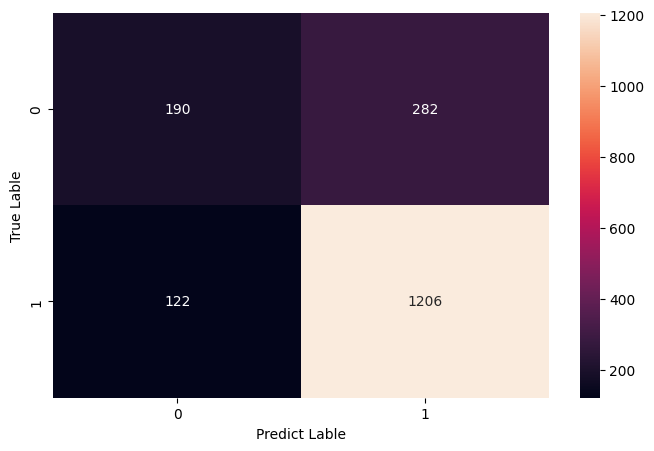

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".0f", ax=ax)
plt.xlabel("Predict Lable")
plt.ylabel("True Lable")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

#[https://medium.com/@ksnugroho/confusion-matrix-untuk-evaluasi-model-pada-unsupervised-machine-learning-bc4b1ae9ae3f]

              precision    recall  f1-score   support

           0       0.61      0.40      0.48       472
           1       0.81      0.91      0.86      1328

    accuracy                           0.78      1800
   macro avg       0.71      0.66      0.67      1800
weighted avg       0.76      0.78      0.76      1800



1. Accuracy = tingkat kedekatan nilai prediksi dengan nilai aktual
2. precision = rasio kedekatan true positif dengan keseluruhan hasil prediksi positif
3. recall = rasio kedekatan true positif dengan keseluruhan hasil
4. f1-score = rata-rata dari precision dan recall


[https://medium.com/@kennymiyasato/classification-report-precision-recall-f1-score-accuracy-16a245a437a5]

In [ ]:
#Testing Model
dataT = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/example_case1.csv", delimiter=";")
dataT.head()

,customerID,gender,Partner,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
0,6733-LRIZX,Male,No,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Yes
1,9503-XJUME,Male,No,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
2,4367-NHWMM,Female,No,No,DSL,No,No,No,No,No,No,Yes
3,3727-RJMEO,Male,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Yes
4,3779-OSWCF,Female,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,No


In [ ]:
#gender
genderT = {'Male': 1,'Female': 0}
dataT.gender = [genderT[itemgenderT] for itemgenderT in dataT.gender]

#Partner
PartnerT = {'Yes': 1,'No': 0}
dataT.Partner = [PartnerT[itempartnerT] for itempartnerT in dataT.Partner]

#PhoneService
PhoneServiceT = {'Yes': 1,'No': 0}
dataT.PhoneService = [PhoneServiceT[itemPhoneServiceT] for itemPhoneServiceT in dataT.PhoneService]

#InternetService
InternetServiceT = {'Fiber optic': 3,'DSL': 2,'No': 1}
dataT.InternetService = [InternetServiceT[itemInternetServiceT] for itemInternetServiceT in dataT.InternetService]

#OnlineSecurity
OnlineSecurityT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.OnlineSecurity = [OnlineSecurityT[itemOnlineSecurityT] for itemOnlineSecurityT in dataT.OnlineSecurity]

#OnlineBackup
OnlineBackupT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.OnlineBackup = [OnlineBackupT[itemOnlineBackupT] for itemOnlineBackupT in dataT.OnlineBackup]

#DeviceProtection
DeviceProtectionT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.DeviceProtection = [DeviceProtectionT[itemDeviceProtectionT] for itemDeviceProtectionT in dataT.DeviceProtection]

#TechSupport
TechSupportT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.TechSupport = [TechSupportT[itemTechSupportT] for itemTechSupportT in dataT.TechSupport]

#StreamingTV
StreamingTVT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.StreamingTV = [StreamingTVT[itemStreamingTVT] for itemStreamingTVT in dataT.StreamingTV]

#StreamingMovies
StreamingMoviesT = {'Yes': 3,'No': 2,'No internet service': 1}
dataT.StreamingMovies = [StreamingMoviesT[itemStreamingMoviesT] for itemStreamingMoviesT in dataT.StreamingMovies]

#PaperlessBilling
PaperlessBillingT = {'Yes': 1,'No': 0}
dataT.PaperlessBilling = [PaperlessBillingT[itemPaperlessBillingT] for itemPaperlessBillingT in dataT.PaperlessBilling]



In [ ]:
dfT = pd.DataFrame(dataT)
y_pred=logistic_regression.predict(dfT[['gender','Partner','PhoneService','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']])

In [ ]:
dfT["churn"] = (y_pred)

In [ ]:
print(dfT)
dfT["churn"].value_counts()

      customerID  gender  Partner  PhoneService  InternetService  \
0     6733-LRIZX       1        0             1                3   
1     9503-XJUME       1        0             1                1   
2     4367-NHWMM       0        0             0                2   
3     3727-RJMEO       1        1             1                3   
4     3779-OSWCF       0        1             1                2   
...          ...     ...      ...           ...              ...   
1039  6840-RESVB       1        1             1                2   
1040  2234-XADUH       0        1             1                3   
1041  4801-JZAZL       0        1             0                2   
1042  8361-LTMKD       1        1             1                3   
1043  3186-AJIEK       1        0             1                3   

      OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0                  3             2                 3            3   
1                  1             1           

,count
churn,
1,863
0,181


In [ ]:
#Grafik
import matplotlib.pyplot as plt

In [ ]:
churn = {0: 'yes', 1: 'No'}
dfT.churn = [churn[itemchrun] for itemchrun in dfT.churn]

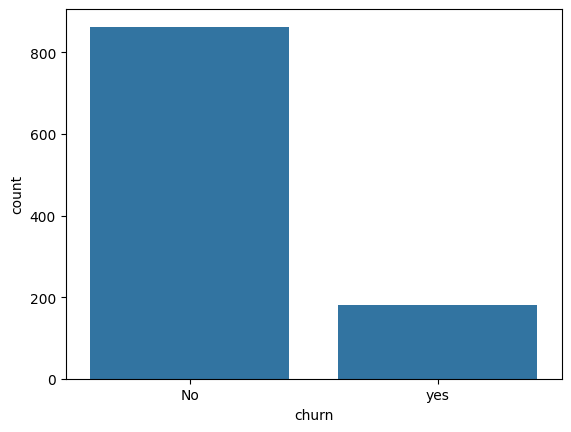

In [ ]:

sns.countplot(x='churn', data=dfT)
plt.show()

In [ ]:
PartnerT = {1: 'Partner', 0: "Not"}
dfT.Partner = [PartnerT[itempartnerT] for itempartnerT in dfT.Partner]

Text(0, 0.5, 'Freq')

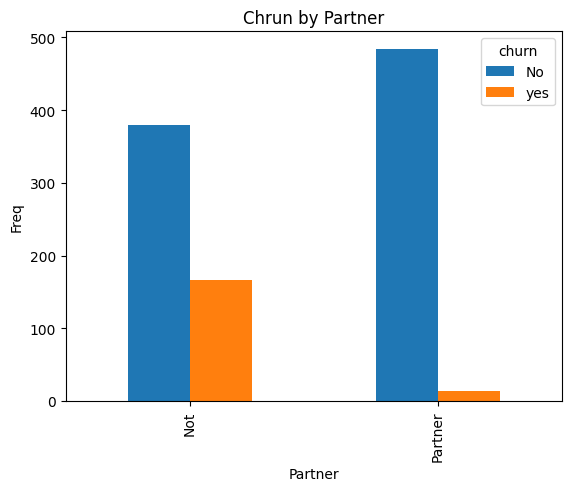

In [ ]:
pd.crosstab(dfT.Partner,dfT.churn).plot(kind='bar')
plt.title('Chrun by Partner')
plt.xlabel('Partner')
plt.ylabel('Freq')

In [ ]:
dfT.to_csv(r'/content/drive/MyDrive/Colab Notebooks/outputSharing.csv')

#Additional Reference

1. [https://towardsdatascience.com/building-a-logistic-regression-in-python-step-by-step-becd4d56c9c8]

2. [https://seaborn.pydata.org/generated/seaborn.histplot.html]

3. [https://towardsdatascience.com/predicting-customer-churn-using-logistic-regression-9543c60f6d47]